In [11]:
# Display tools
from IPython.display import HTML, display  # For HTML rendering in notebooks
import os 
import matplotlib.pyplot as plt
import pandas as pd

In [12]:
import os

def get_dicom_paths(directory_path, label=None, verbose=True):
    """
    Scans a directory for DICOM (.dcm) files and returns their paths.

    Parameters:
    - directory_path (str): Directory to scan for .dcm files
    - label (str, optional): Label for display (e.g., 'train', 'test')
    - verbose (bool): Whether to print the number of files found

    Returns:
    - List[str]: Paths to DICOM files
    """
    dicom_paths = [
        os.path.join(directory_path, file)
        for file in os.listdir(directory_path)
        if file.lower().endswith('.dcm')
    ]
    
    if verbose:
        label_text = f" in the '{label}' directory" if label else ""
        print(f" Found {len(dicom_paths)} DICOM files{label_text}.")
    
    return dicom_paths

# --- Define Image Directories ---
TRAIN_IMG_DIR = r"C:\Users\samya\PyCharmProject\Pneumonia-Detection_dataset\data\stage_2_train_images"
TEST_IMG_DIR  = r"C:\Users\samya\PyCharmProject\Pneumonia-Detection_dataset\data\stage_2_test_images"

# --- Get File Paths ---
train_img_path = get_dicom_paths(TRAIN_IMG_DIR, label="train")
test_img_path  = get_dicom_paths(TEST_IMG_DIR, label="test")


 Found 26684 DICOM files in the 'train' directory.
 Found 3000 DICOM files in the 'test' directory.


In [13]:
labels = pd.read_csv(r"C:\Users\samya\PyCharmProject\Pneumonia-Detection_dataset\data\stage_2_train_labels.csv")
labels.head()

,patientId,x,y,width,height,Target
0,0004cfab-14fd-4e49-80ba-63a80b6bddd6,NaN,NaN,NaN,NaN,0
1,00313ee0-9eaa-42f4-b0ab-c148ed3241cd,NaN,NaN,NaN,NaN,0
2,00322d4d-1c29-4943-afc9-b6754be640eb,NaN,NaN,NaN,NaN,0
3,003d8fa0-6bf1-40ed-b54c-ac657f8495c5,NaN,NaN,NaN,NaN,0
4,00436515-870c-4b36-a041-de91049b9ab4,264.0,152.0,213.0,379.0,1


In [14]:
count_normal = len(labels.loc[labels['Target']==0])
count_pnemonia= len(labels.loc[labels['Target']==1])
traing_count=len(train_img_path)

In [15]:
weight_for_zero =(1/count_normal)*(traing_count)/2.0
weight_for_ones =(1/count_pnemonia)*(traing_count)/2.0

In [16]:
classweight= {0: weight_for_zero,
              1: weight_for_ones}

In [17]:
print("Weights:", classweight)

Weights: {0: 0.6454140866873065, 1: 1.3963369963369963}


In [18]:
def parseMetadata(dcm):  # corrected from 'paraseMetadata'
    unpackedData = {}
    groupElemToKeywords = {}
    
    for d in dcm:  # This forces conversion from lazy RawDataElement to DataElement
        pass

    # Un-pack Data
    for tag, elem in dcm.items():
        tagGroup = tag.group
        tagElem = tag.elem
        keyword = elem.keyword
        groupElemToKeywords[(tagGroup, tagElem)] = keyword
        value = elem.value
        unpackedData[keyword] = value
        
    return unpackedData, groupElemToKeywords


In [19]:
import pydicom
from tqdm import tqdm

In [20]:


# Step 1: Read DICOM files from paths
train_dcms = [pydicom.dcmread(path) for path in tqdm(train_img_path[:5000])]
test_dcms = [pydicom.dcmread(path) for path in tqdm(test_img_path[:5000])]




100%|██████████| 3000/3000 [00:32<00:00, 92.10it/s] 


In [21]:
# Step 2: Parse metadata from DICOM datasets
trainMetaDicts, trainKeyword = zip(*[parseMetadata(dcm) for dcm in tqdm(train_dcms)])
testMetaDicts, testKeyword = zip(*[parseMetadata(dcm) for dcm in tqdm(test_dcms)])

100%|██████████| 3000/3000 [00:01<00:00, 2248.75it/s]


In [22]:
def createY(df):
    """
    Returns binary labels: 1 if 'SeriesDescription' is 'view: PA', else 0.
    """
    if 'SeriesDescription' not in df.columns:
        raise ValueError("Missing 'SeriesDescription' column in DataFrame.")
    
    return (df['SeriesDescription'] == 'view: PA').astype(int).values


In [23]:
train_df = pd.DataFrame.from_dict(data=trainMetaDicts)
test_df = pd.DataFrame.from_dict(data=testMetaDicts)

train_df['dataset'] = 'train'
test_df['dataset'] = 'test'

train_Y = createY(train_df)
test_Y = createY(test_df)


In [24]:
def decodeImage(filePath):
    image = pydicom.dcmread(filePath).pixel_array
    image = cv2.resize(image, (64, 64))
    return image / 255.0


In [25]:

import cv2
import numpy as np

# Get our train x in the correct shape
train_X = []

for filePath in tqdm(train_img_path[:5000]):
    
    img = decodeImage(filePath)
    train_X.append(img)


train_X = np.array(train_X) # Convert to np.array
train_X_rgb = np.repeat(train_X[..., np.newaxis], 3, -1) # Reshape into rgb format

100%|██████████| 5000/5000 [00:27<00:00, 179.16it/s]


In [26]:
test_X =[]
for filePath in tqdm(test_img_path[:5000]):
    
    img = decodeImage(filePath)
    test_X.append(img)

test_X = np.array(test_X) # Convert to np array
test_X_rgb = np.repeat(test_X[..., np.newaxis], 3, -1) # Reshape into rgb format

100%|██████████| 3000/3000 [00:15<00:00, 199.68it/s]


In [27]:
import tensorflow as tf

In [28]:
from tensorflow import keras
from tensorflow.keras.layers import *
from tensorflow.keras import Model


In [29]:
import matplotlib.pyplot as plt

def plot_score(hist):
    fig, ax = plt.subplots(5, 1, figsize=(10, 20))  # Corrected 'subplot' to 'subplots'
    ax = ax.ravel()

    for i, met in enumerate(['accuracy', 'precision', 'recall', 'AUC', 'loss']):
        ax[i].plot(hist.history[met])
        ax[i].plot(hist.history['val_' + met])
        ax[i].set_title(f'Model {met}')
        ax[i].set_xlabel('Epochs')
        ax[i].set_ylabel(met)
        ax[i].legend(['Train', 'Validation'])

    plt.tight_layout()
    plt.show()


In [30]:
# These our our scoring metrics that are going to be used to evaluate our models
METRICS = ['accuracy', 
           tf.keras.metrics.Precision(name='precision'), 
           tf.keras.metrics.Recall(name='recall'), 
           tf.keras.metrics.AUC(name='AUC')]

In [31]:
import tensorflow as tf

# Clear, Flexible Exponential Decay Function
def exponential_decay(lr_initial, decay_steps, decay_rate=0.1):
    """
    Returns a function that computes exponentially decaying learning rate.
    
    Parameters:
    - lr_initial: Initial learning rate
    - decay_steps: Controls the rate of decay
    - decay_rate: The base of the exponential decay (default: 0.1)

    Returns:
    - A function that takes an epoch index and returns the decayed learning rate
    """
    def schedule(epoch):
        return lr_initial * decay_rate ** (epoch / decay_steps)
    return schedule

# Define the scheduler function
exponential_decay_fn = exponential_decay(lr_initial=0.01, decay_steps=20)

# Learning Rate Scheduler Callback
lr_scheduler_cb = tf.keras.callbacks.LearningRateScheduler(exponential_decay_fn, verbose=1)

# Model Checkpoint Callback (saves best model only)
checkpoint_cb = tf.keras.callbacks.ModelCheckpoint(
    filepath="xray_model.h5",
    save_best_only=True,
    monitor="val_loss",
    mode="min",
    verbose=1
)

# Early Stopping Callback (restores best weights after patience period)
early_stopping_cb = tf.keras.callbacks.EarlyStopping(
    patience=5,
    restore_best_weights=True,
    monitor="val_loss",
    mode="min",
    verbose=1
)


In [32]:
import pandas as pd
import numpy as np
from PIL import Image, ImageDraw

# Parameters
image_size = (64, 64)  # Target mask size
csv_path = 'la.csv'  # Path to your CSV file

# Load bounding box annotations
df = labels.copy()

# Filter rows with pneumonia (Target == 1)
df = df[df['Target'] == 1]

# Group bounding boxes by patient ID
grouped = df.groupby('patientId')

# Dictionary to store masks
masks = {}

# Generate binary masks
for patient_id, rows in grouped:
    mask = Image.new('L', image_size, 0)
    draw = ImageDraw.Draw(mask)

    for _, row in rows.iterrows():
        x, y, w, h = row['x'], row['y'], row['width'], row['height']
        scale_x = image_size[0] / 1024
        scale_y = image_size[1] / 1024
        x1 = int(x * scale_x)
        y1 = int(y * scale_y)
        x2 = int((x + w) * scale_x)
        y2 = int((y + h) * scale_y)
        draw.rectangle([x1, y1, x2, y2], fill=1)

    masks[patient_id] = np.array(mask)


In [33]:
import os
import numpy as np
import pandas as pd
import pydicom
import cv2

# --- Configuration ---
TRAIN_IMG_DIR = r"C:\Users\samya\PyCharmProject\Pneumonia-Detection_dataset\data\stage_2_train_images"
CSV_PATH = r"C:\Users\samya\PyCharmProject\Pneumonia-Detection_dataset\data\stage_2_train_labels.csv"
OUTPUT_DIR = "npy_images"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# --- Load CSV and filter for annotated images (Target == 1) ---
#df = pd.read_csv(CSV_PATH)
annotated_ids = df[df['Target'] == 1]['patientId'].unique()

# --- Convert DICOM to 64x64 RGB .npy ---
def convert_dicom_to_npy(dicom_path):
    ds = pydicom.dcmread(dicom_path)
    img = ds.pixel_array.astype(np.float32)
    img -= np.min(img)
    img /= np.max(img)
    img *= 255.0
    img = img.astype(np.uint8)
    img_resized = cv2.resize(img, (64, 64))
    img_rgb = cv2.cvtColor(img_resized, cv2.COLOR_GRAY2RGB)
    return img_rgb

# --- Process and save ---
for patient_id in annotated_ids:
    dicom_file = os.path.join(TRAIN_IMG_DIR, f"{patient_id}.dcm")
    if os.path.exists(dicom_file):
        try:
            img_rgb = convert_dicom_to_npy(dicom_file)
            np.save(os.path.join(OUTPUT_DIR, f"{patient_id}.npy"), img_rgb)
        except Exception as e:
            print(f"Failed to process {patient_id}: {e}")

print("Annotated DICOM images converted to 64x64 RGB .npy files.")


Annotated DICOM images converted to 64x64 RGB .npy files.


In [34]:
""" import numpy as np
from tensorflow.keras import layers, models, Input
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

# --- U-Net Model Definition ---
def build_unet(input_shape=(64, 64, 3)):
    inputs = Input(input_shape)

    def conv_block(x, filters):
        x = layers.Conv2D(filters, 3, activation='relu', padding='same')(x)
        x = layers.Conv2D(filters, 3, activation='relu', padding='same')(x)
        return x

    def encoder_block(x, filters):
        f = conv_block(x, filters)
        p = layers.MaxPooling2D(pool_size=(2, 2))(f)
        return f, p

    def decoder_block(x, skip, filters):
        x = layers.Conv2DTranspose(filters, kernel_size=2, strides=2, padding='same')(x)
        x = layers.Concatenate()([x, skip])
        return conv_block(x, filters)

    # Encoder
    f1, p1 = encoder_block(inputs, 32)
    f2, p2 = encoder_block(p1, 64)
    f3, p3 = encoder_block(p2, 128)

    # Bottleneck
    b = conv_block(p3, 256)

    # Decoder
    d1 = decoder_block(b, f3, 128)
    d2 = decoder_block(d1, f2, 64)
    d3 = decoder_block(d2, f1, 32)

    # Output
    outputs = layers.Conv2D(1, 1, activation='sigmoid')(d3)

    return models.Model(inputs, outputs, name='UNet')

# --- Dummy Data (Replace with your actual data) ---
X_train = np.random.rand(100, 64, 64, 3)
y_train = np.random.randint(0, 2, (100, 64, 64, 1))
X_val = np.random.rand(20, 64, 64, 3)
y_val = np.random.randint(0, 2, (20, 64, 64, 1))

# --- Training Parameters ---
BATCH_SIZE = 16
EPOCHS = 10
METRICS = ['accuracy']

# --- Callbacks ---
checkpoint_cb = ModelCheckpoint('unet_model.h5', save_best_only=True)
early_stopping_cb = EarlyStopping(patience=3, restore_best_weights=True)
lr_scheduler_cb = ReduceLROnPlateau(factor=0.5, patience=2)

# --- Compile and Train ---
model = build_unet((64, 64, 3))
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=METRICS)
history_unet = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    callbacks=[checkpoint_cb, early_stopping_cb, lr_scheduler_cb]
)

# --- Model Summary ---
model.summary()
"""

" import numpy as np\nfrom tensorflow.keras import layers, models, Input\nfrom tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau\n\n# --- U-Net Model Definition ---\ndef build_unet(input_shape=(64, 64, 3)):\n    inputs = Input(input_shape)\n\n    def conv_block(x, filters):\n        x = layers.Conv2D(filters, 3, activation='relu', padding='same')(x)\n        x = layers.Conv2D(filters, 3, activation='relu', padding='same')(x)\n        return x\n\n    def encoder_block(x, filters):\n        f = conv_block(x, filters)\n        p = layers.MaxPooling2D(pool_size=(2, 2))(f)\n        return f, p\n\n    def decoder_block(x, skip, filters):\n        x = layers.Conv2DTranspose(filters, kernel_size=2, strides=2, padding='same')(x)\n        x = layers.Concatenate()([x, skip])\n        return conv_block(x, filters)\n\n    # Encoder\n    f1, p1 = encoder_block(inputs, 32)\n    f2, p2 = encoder_block(p1, 64)\n    f3, p3 = encoder_block(p2, 128)\n\n    # Bottleneck\n 

In [35]:
from tensorflow.keras import layers, models, Input

def build_unet(input_shape=(128, 128, 1)):
    inputs = Input(input_shape)

    # --- Encoder ---
    def conv_block(x, filters):
        x = layers.Conv2D(filters, 3, activation='relu', padding='same')(x)
        x = layers.Conv2D(filters, 3, activation='relu', padding='same')(x)
        return x

    def encoder_block(x, filters):
        f = conv_block(x, filters)
        p = layers.MaxPooling2D(pool_size=(2, 2))(f)
        return f, p

    def decoder_block(x, skip, filters):
        x = layers.Conv2DTranspose(filters, kernel_size=2, strides=2, padding='same')(x)
        x = layers.Concatenate()([x, skip])
        return conv_block(x, filters)

    # Downsampling path
    f1, p1 = encoder_block(inputs, 32)
    f2, p2 = encoder_block(p1, 64)
    f3, p3 = encoder_block(p2, 128)

    # Bottleneck
    b = conv_block(p3, 256)

    # Upsampling path
    d1 = decoder_block(b, f3, 128)
    d2 = decoder_block(d1, f2, 64)
    d3 = decoder_block(d2, f1, 32)

    # Output layer
    outputs = layers.Conv2D(1, 1, activation='sigmoid')(d3)

    model = models.Model(inputs, outputs, name='UNet')
    return model

In [36]:
model = build_unet((64, 64, 3))
model.summary()

Model: "UNet"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 64, 64, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 64, 64,    │        896 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 64, 64,    │      9,248 │ conv2d[0][0]      │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 32, 32,    │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 32, 32,    │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 32, 32,    │     36,928 │ conv2d_2[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 16, 16,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 16, 16,    │     73,856 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 16, 16,    │    147,584 │ conv2d_4[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 8, 8, 128) │          0 │ conv2d_5[0][0]    │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 8, 8, 256) │    295,168 │ max_pooling2d_2[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 8, 8, 256) │    590,080 │ conv2d_6[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose    │ (None, 16, 16,    │    131,200 │ conv2d_7[0][0]    │
│ (Conv2DTranspose)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 16, 16,    │          0 │ conv2d_transpose… │
│ (Concatenate)       │ 256)              │            │ conv2d_5[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 16, 16,    │    295,040 │ concatenate[0][0] │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 16, 16,    │    147,584 │ conv2d_8[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_1  │ (None, 32, 32,    │     32,832 │ conv2d_9[0][0]    │
│ (Conv2DTranspose)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 1,925,601 (7.35 MB)

 Trainable params: 1,925,601 (7.35 MB)

 Non-trainable params: 0 (0.00 B)

In [37]:
# --- Compile and Train ---
#train_X_rgb = np.repeat(train_X[..., np.newaxis], 3, -1)
model = build_unet((64, 64, 3))
model.compile(optimizer='adam', loss='binary_crossentropy',
              metrics=METRICS)
history_unet=model.fit(X_train, y_train, validation_data=(X_val, y_val), batch_size=BATCH_SIZE, epochs=EPOCHS,callbacks=[checkpoint_cb, early_stopping_cb, lr_scheduler_cb])

NameError: name 'X_train' is not defined

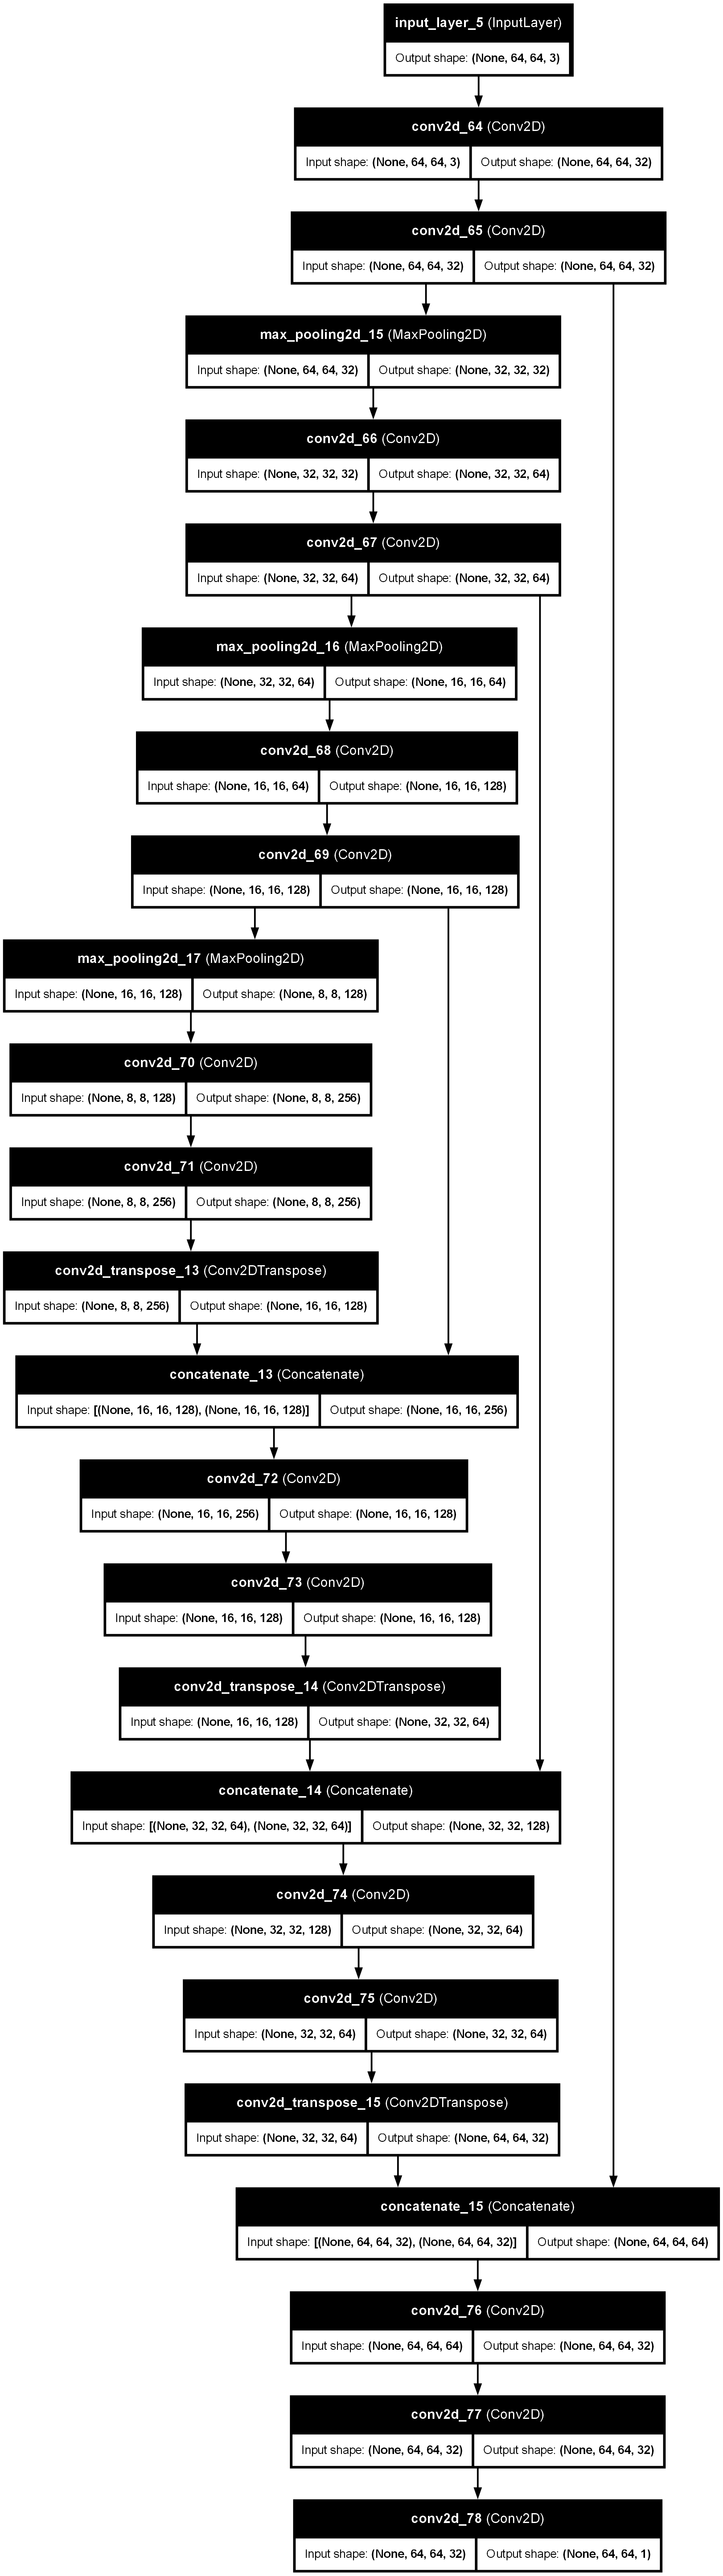

In [ ]:
from tensorflow.keras.utils import plot_model

plot_model(model, show_shapes=True, show_layer_names=True, to_file="unet_model.png")


Using DICOM file: C:\Users\samya\PyCharmProject\Pneumonia-Detection_dataset\data\stage_2_train_images\fa8b38fd-e95d-4484-96cd-01def7c6dd98.dcm
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 592ms/step


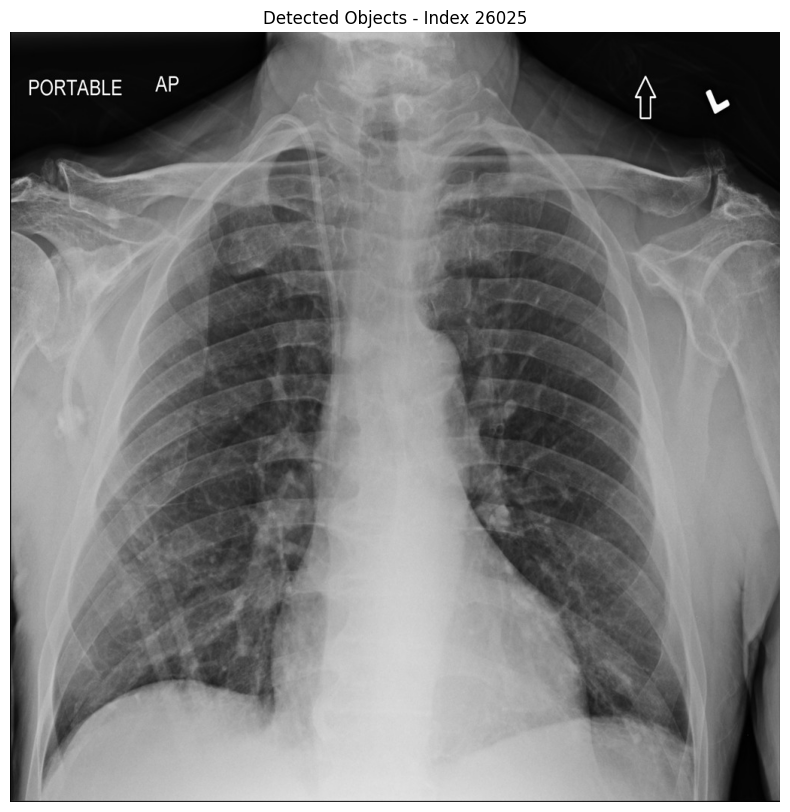

In [ ]:
import os
import random
import numpy as np
import cv2
import matplotlib.pyplot as plt
import pydicom
from tensorflow.keras.models import load_model

# --- Define DICOM path loader ---
def get_dicom_paths(directory):
    return [os.path.join(directory, fname) for fname in os.listdir(directory) if fname.endswith(".dcm")]

# --- Directories ---
TRAIN_IMG_DIR = r"C:\Users\samya\PyCharmProject\Pneumonia-Detection_dataset\data\stage_2_train_images"
train_img_path = get_dicom_paths(TRAIN_IMG_DIR)

# --- Load U-Net model ---
model = load_model(r'C:\Users\samya\PyCharmProject\Pneumonia-Detection\xray_model.h5')  # Replace with your actual model path

# --- Select a random image beyond the first 5000 ---
random_index = random.choice(range(5000, len(train_img_path)))
dicom_path = train_img_path[random_index]
print(f"Using DICOM file: {dicom_path}")

# --- Load and preprocess DICOM image ---
dicom = pydicom.dcmread(dicom_path)
image = dicom.pixel_array.astype(np.float32)
image = cv2.normalize(image, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
original_size = image.shape

# Resize to model input size and convert to 3 channels
input_image = cv2.resize(image, (64, 64))
input_image = cv2.cvtColor(input_image, cv2.COLOR_GRAY2RGB)
input_image = input_image / 255.0
input_image = np.expand_dims(input_image, axis=0)  # Shape: (1, 64, 64, 3)

# --- Predict segmentation mask ---
predicted_mask = model.predict(input_image)[0, :, :, 0]
binary_mask = (predicted_mask > 0.5).astype(np.uint8) * 255
binary_mask_resized = cv2.resize(binary_mask, (original_size[1], original_size[0]))

# --- Find contours and draw bounding boxes ---
contours, _ = cv2.findContours(binary_mask_resized, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
output_image = cv2.cvtColor(image, cv2.COLOR_GRAY2BGR)

for cnt in contours:
    x, y, w, h = cv2.boundingRect(cnt)
    cv2.rectangle(output_image, (x, y), (x + w, y + h), (0, 255, 0), 2)

# --- Display result ---
plt.figure(figsize=(10, 10))
plt.imshow(output_image)
plt.title(f"Detected Objects - Index {random_index}")
plt.axis('off')
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 346ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step


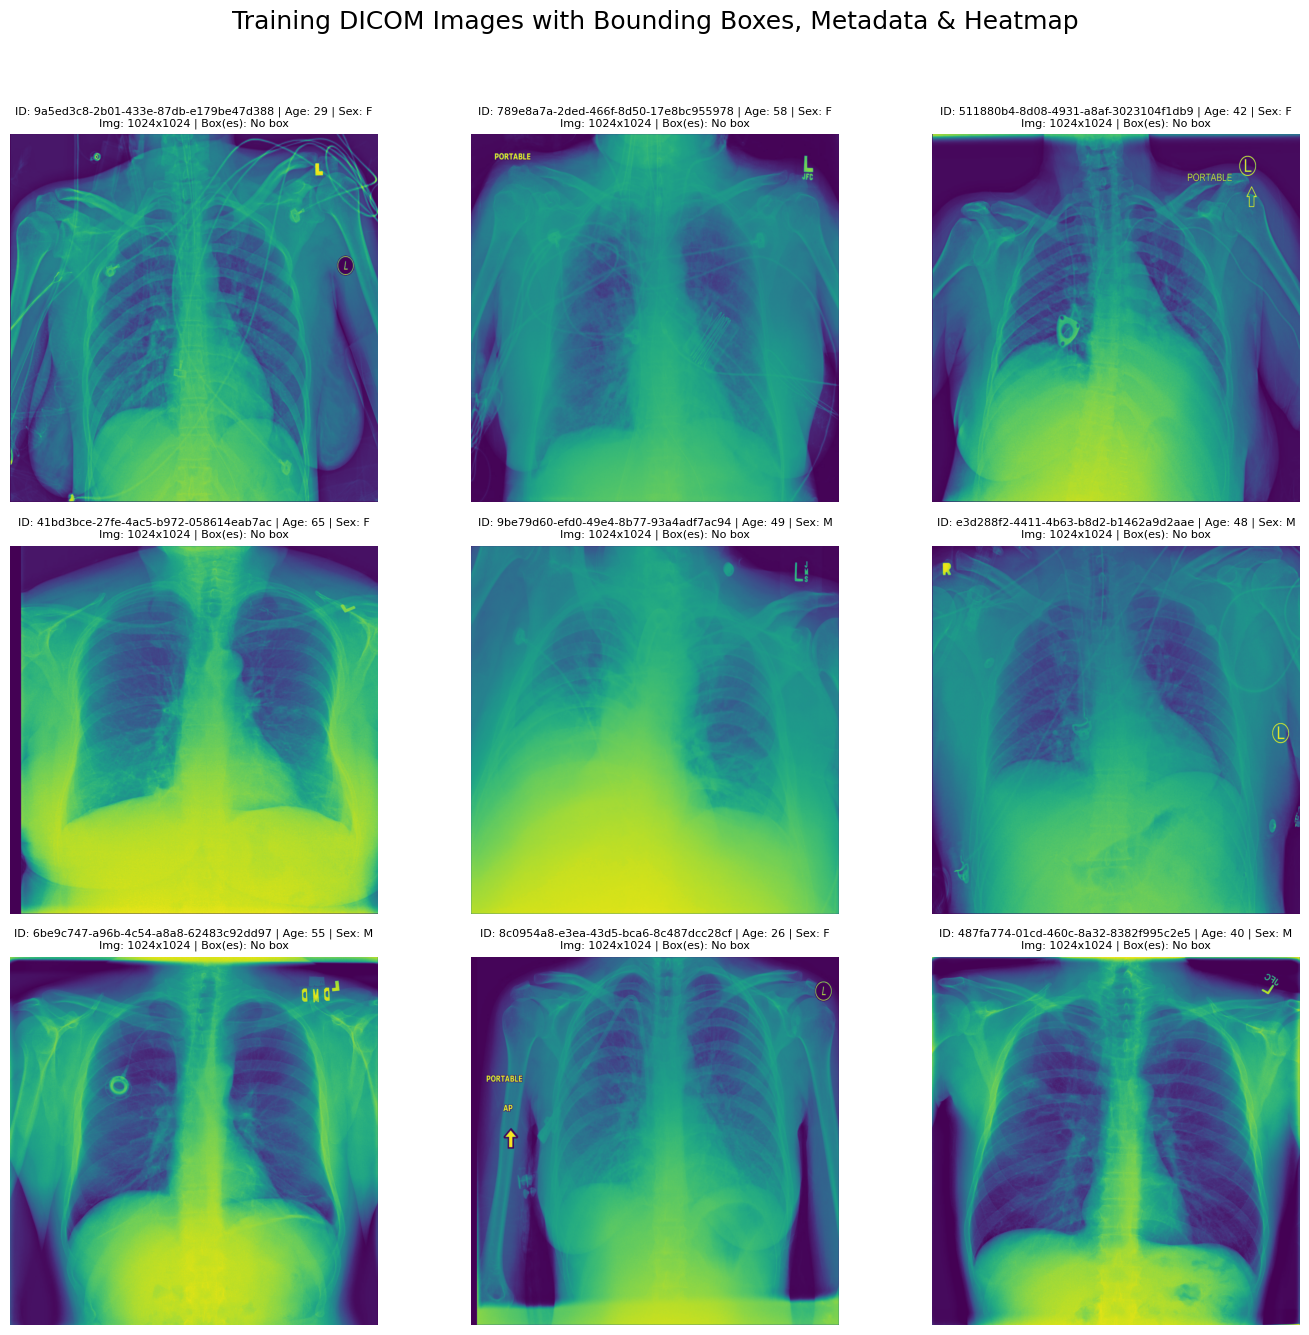

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step


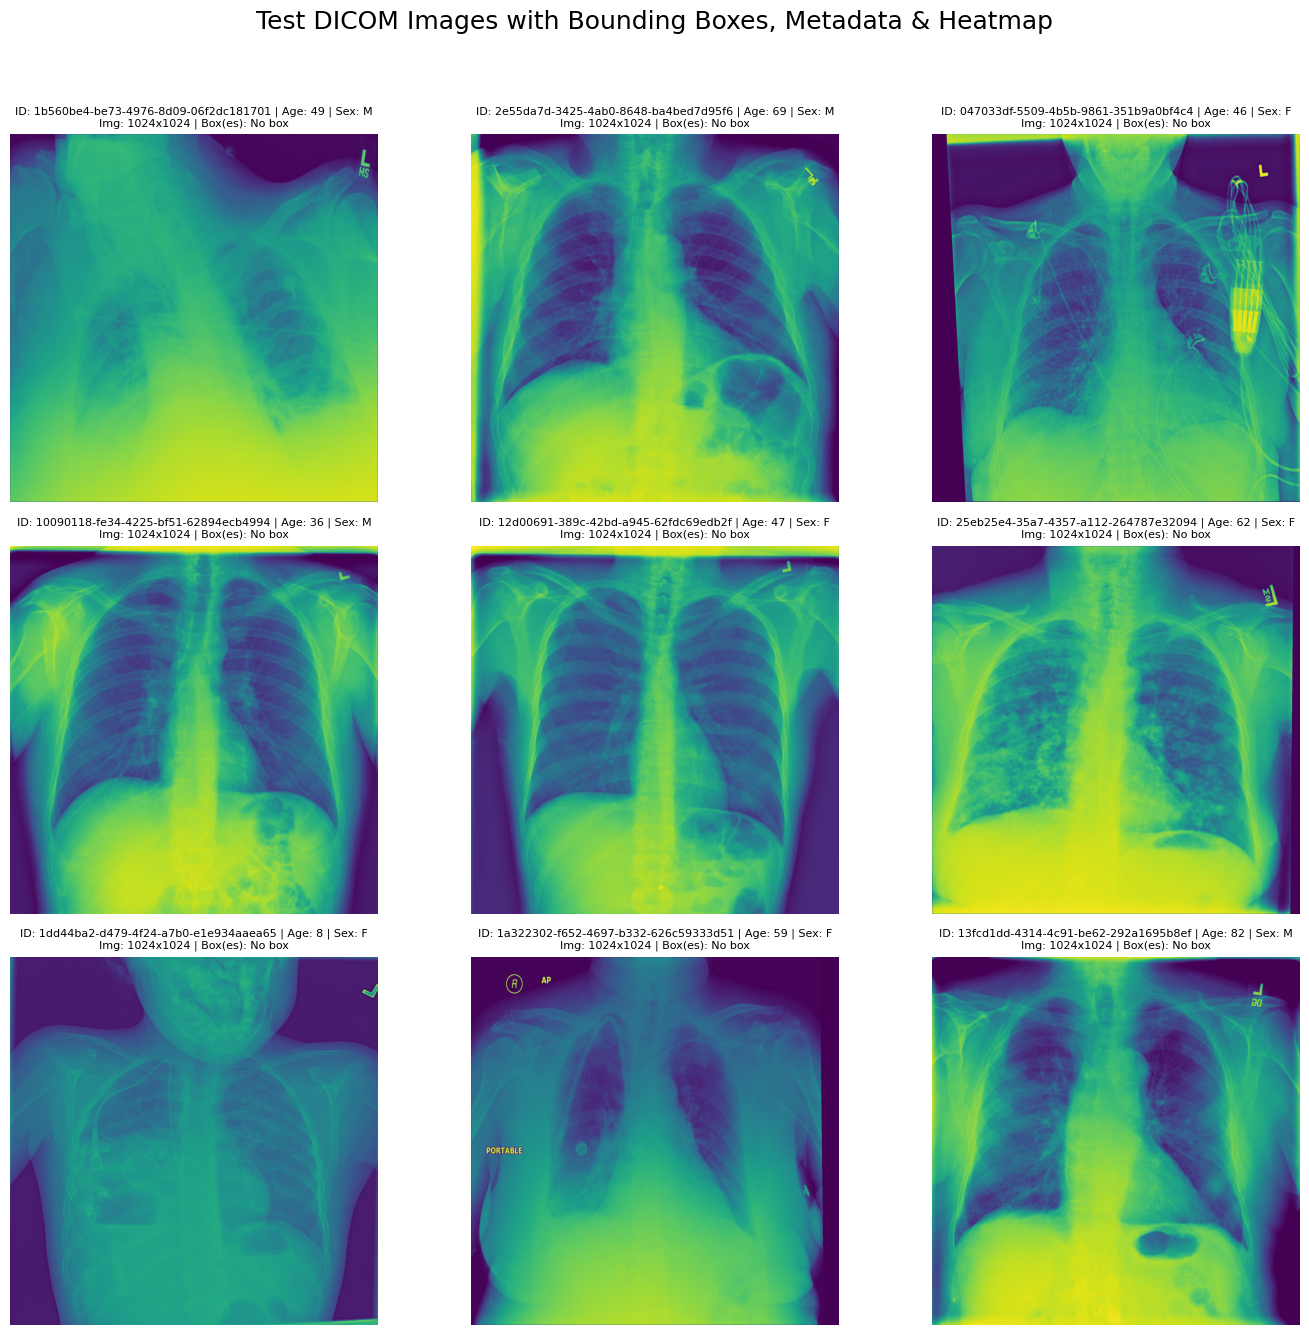

In [ ]:
import os
import random
import numpy as np
import cv2
import matplotlib.pyplot as plt
import pydicom
from tensorflow.keras.models import load_model

# --- Define DICOM path loader ---
def get_dicom_paths(directory):
    return [os.path.join(directory, fname) for fname in os.listdir(directory) if fname.endswith(".dcm")]

# --- Directories ---
TRAIN_IMG_DIR = r"C:\Users\samya\PyCharmProject\Pneumonia-Detection_dataset\data\stage_2_train_images"
TEST_IMG_DIR  = r"C:\Users\samya\PyCharmProject\Pneumonia-Detection_dataset\data\stage_2_test_images"
MODEL_PATH    = r'C:\Users\samya\PyCharmProject\Pneumonia-Detection\xray_model.h5'

# --- Load U-Net model ---
model = load_model(MODEL_PATH)

# --- Load paths ---
train_img_paths = get_dicom_paths(TRAIN_IMG_DIR)
test_img_paths = get_dicom_paths(TEST_IMG_DIR)

# --- Function to process and visualize with heatmap, predictions, and metadata ---
def process_and_display_with_boxes(image_paths, title):
    fig, axes = plt.subplots(3, 3, figsize=(14, 14))
    fig.suptitle(title, fontsize=18)

    for ax, path in zip(axes.flatten(), image_paths):
        ds = pydicom.dcmread(path)
        image = ds.pixel_array.astype(np.float32)
        image = cv2.normalize(image, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
        original_size = image.shape

        # Resize and prepare for model
        input_image = cv2.resize(image, (64, 64))
        input_image_rgb = cv2.cvtColor(input_image, cv2.COLOR_GRAY2RGB)
        input_image_norm = input_image_rgb / 255.0
        input_image_norm = np.expand_dims(input_image_norm, axis=0)

        # Predict and threshold
        predicted_mask = model.predict(input_image_norm)[0, :, :, 0]
        binary_mask = (predicted_mask > 0.5).astype(np.uint8) * 255
        binary_mask_resized = cv2.resize(binary_mask, (original_size[1], original_size[0]))

        # Apply heatmap to original grayscale image
        heatmap_image = cv2.applyColorMap(image, cv2.COLORMAP_VIRIDIS)


        # Find contours and draw bounding boxes
        contours, _ = cv2.findContours(binary_mask_resized, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        output_image = heatmap_image.copy()
        box_labels = []

        for cnt in contours:
            x, y, w, h = cv2.boundingRect(cnt)
            cv2.rectangle(output_image, (x, y), (x + w, y + h), (0, 255, 0), 2)  # Green box
            box_labels.append(f"{w}x{h}")

        # --- Extract metadata ---
        patient_id = getattr(ds, "PatientID", "N/A")
        patient_age = getattr(ds, "PatientAge", "N/A")
        patient_sex = getattr(ds, "PatientSex", "N/A")
        dimensions = f"{original_size[0]}x{original_size[1]}"
        box_str = "; ".join(box_labels) if box_labels else "No box"

        # --- Show image ---
        ax.imshow(cv2.cvtColor(output_image, cv2.COLOR_BGR2RGB))
        ax.axis('off')
        ax.set_title(
            f"ID: {patient_id} | Age: {patient_age} | Sex: {patient_sex}\n"
            f"Img: {dimensions} | Box(es): {box_str}",
            fontsize=8
        )

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])  # Leave room for suptitle
    plt.show()

# --- Randomly select 9 images from train and test ---
train_samples = random.sample(train_img_paths, 9)
test_samples = random.sample(test_img_paths, 9)

# --- Plot with heatmap, predictions, boxes, and metadata ---
process_and_display_with_boxes(train_samples, "Training DICOM Images with Bounding Boxes, Metadata & Heatmap")
process_and_display_with_boxes(test_samples, "Test DICOM Images with Bounding Boxes, Metadata & Heatmap")


In [ ]:
import os
import random
import numpy as np
import cv2
import matplotlib.pyplot as plt
import pydicom
from tensorflow.keras.models import load_model

# --- Define DICOM path loader ---
def get_dicom_paths(directory):
    return [os.path.join(directory, fname) for fname in os.listdir(directory) if fname.endswith(".dcm")]

# --- Directories ---
TRAIN_IMG_DIR = r"C:\Users\samya\PyCharmProject\Pneumonia-Detection_dataset\data\stage_2_train_images"
TEST_IMG_DIR  = r"C:\Users\samya\PyCharmProject\Pneumonia-Detection_dataset\data\stage_2_test_images"
MODEL_PATH    = r'C:\Users\samya\PyCharmProject\Pneumonia-Detection\xray_model.h5'

# --- Load U-Net model ---
model = load_model(MODEL_PATH)

# --- Load paths ---
train_img_paths = get_dicom_paths(TRAIN_IMG_DIR)
test_img_paths = get_dicom_paths(TEST_IMG_DIR)

# --- Function to process and visualize with heatmap, predictions, and metadata ---
def process_and_display_with_boxes(image_paths, title):
    fig, axes = plt.subplots(2, 2, figsize=(14, 14))
    fig.suptitle(title, fontsize=18)

    for ax, path in zip(axes.flatten(), image_paths):
        ds = pydicom.dcmread(path)
        image = ds.pixel_array.astype(np.float32)
        image = cv2.normalize(image, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
        original_size = image.shape

        # Resize and prepare for model
        input_image = cv2.resize(image, (64, 64))
        input_image_rgb = cv2.cvtColor(input_image, cv2.COLOR_GRAY2RGB)
        input_image_norm = input_image_rgb / 255.0
        input_image_norm = np.expand_dims(input_image_norm, axis=0)

        # Predict and threshold
        predicted_mask = model.predict(input_image_norm)[0, :, :, 0]
        binary_mask = (predicted_mask > 0.5).astype(np.uint8) * 255
        binary_mask_resized = cv2.resize(binary_mask, (original_size[1], original_size[0]))

        # Apply VIRIDIS colormap to original grayscale image
        heatmap_image = cv2.applyColorMap(image, cv2.COLORMAP_VIRIDIS)

        # Find contours and draw red bounding boxes
        contours, _ = cv2.findContours(binary_mask_resized, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        output_image = heatmap_image.copy()
        box_labels = []

        for cnt in contours:
            x, y, w, h = cv2.boundingRect(cnt)
            cv2.rectangle(output_image, (x, y), (x + w, y + h), (0, 0, 255), 2)  
            box_labels.append(f"{w}x{h}")

        # --- Extract metadata ---
        patient_id = getattr(ds, "PatientID", "N/A")
        patient_age = getattr(ds, "PatientAge", "N/A")
        patient_sex = getattr(ds, "PatientSex", "N/A")
        view_pos = getattr(ds, "ViewPosition", "N/A")
        dimensions = f"{original_size[0]}x{original_size[1]}"
        box_str = "; ".join(box_labels) if box_labels else "No box"

        # --- Show image ---
        ax.imshow(cv2.cvtColor(output_image, cv2.COLOR_BGR2RGB))
        ax.axis('off')
        ax.set_title(
            f"ID: {patient_id} | Age: {patient_age} | Sex: {patient_sex} | View: {view_pos}\n"
            f"Size: {dimensions} | Box(es): {box_str}",
            fontsize=8
        )

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])  # Leave room for suptitle
    plt.show()

# --- Randomly select 9 images from train and test ---
train_samples = random.sample(train_img_paths, 9)
test_samples = random.sample(test_img_paths, 9)




1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 294ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step


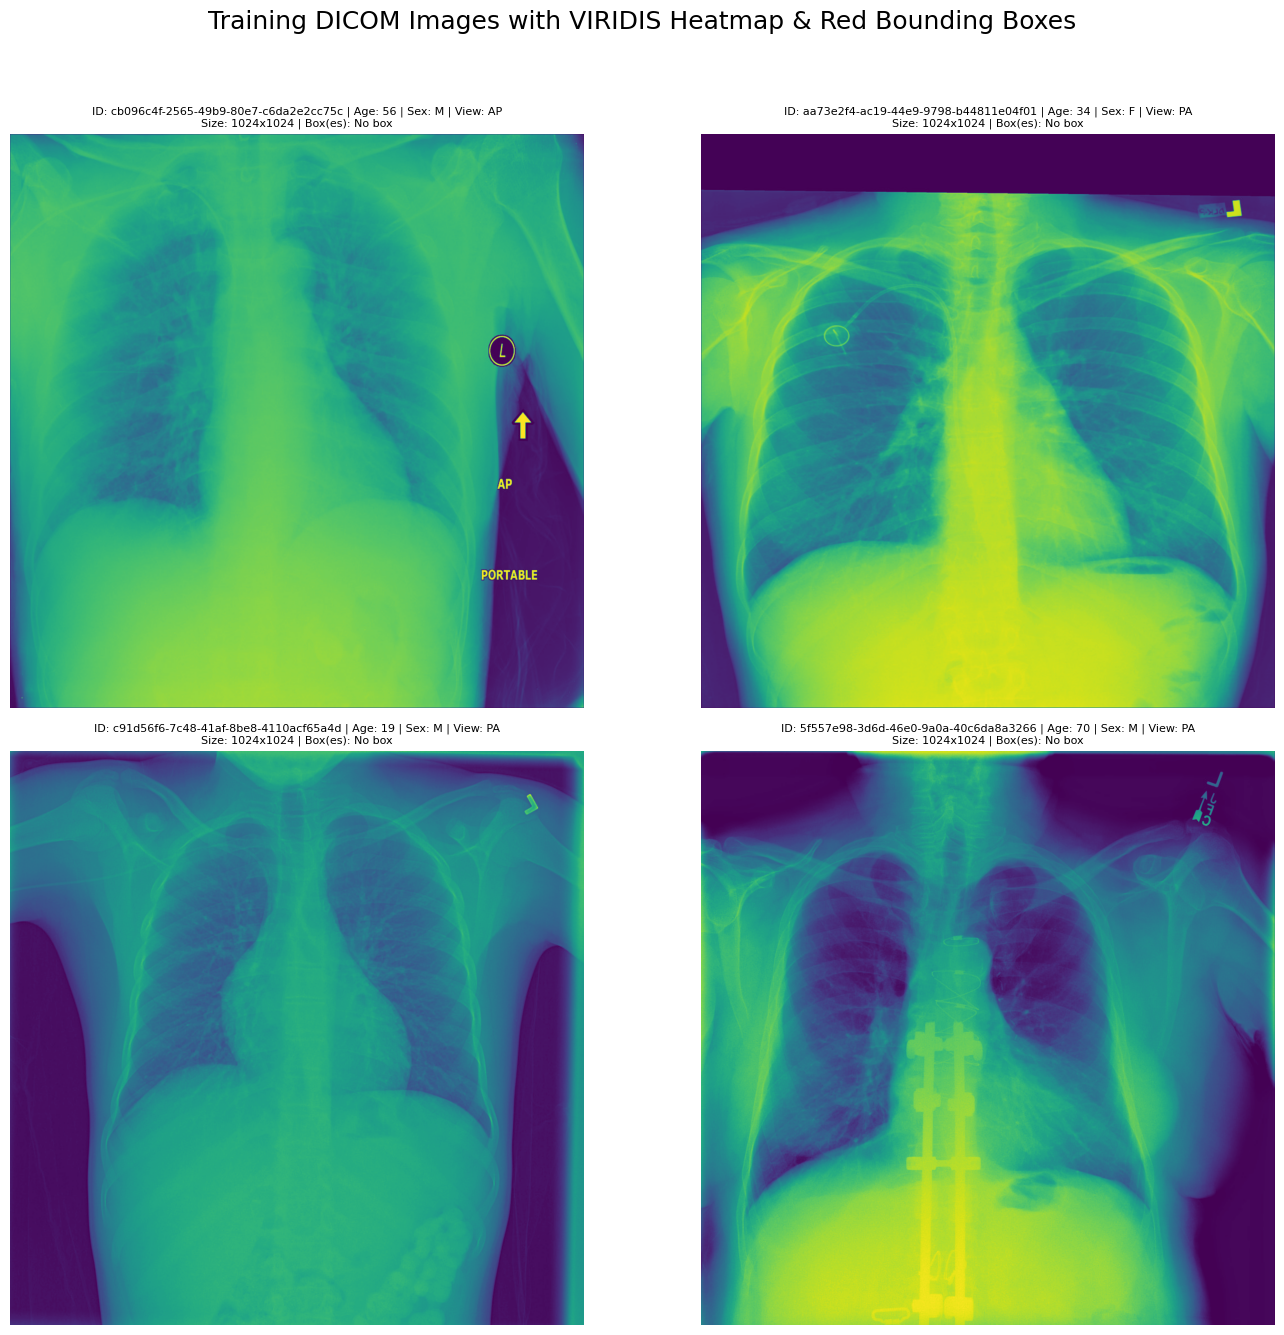

In [ ]:
# --- Plot with heatmap, predictions, boxes, and metadata ---
process_and_display_with_boxes(train_samples, "Training DICOM Images with VIRIDIS Heatmap & Red Bounding Boxes")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step


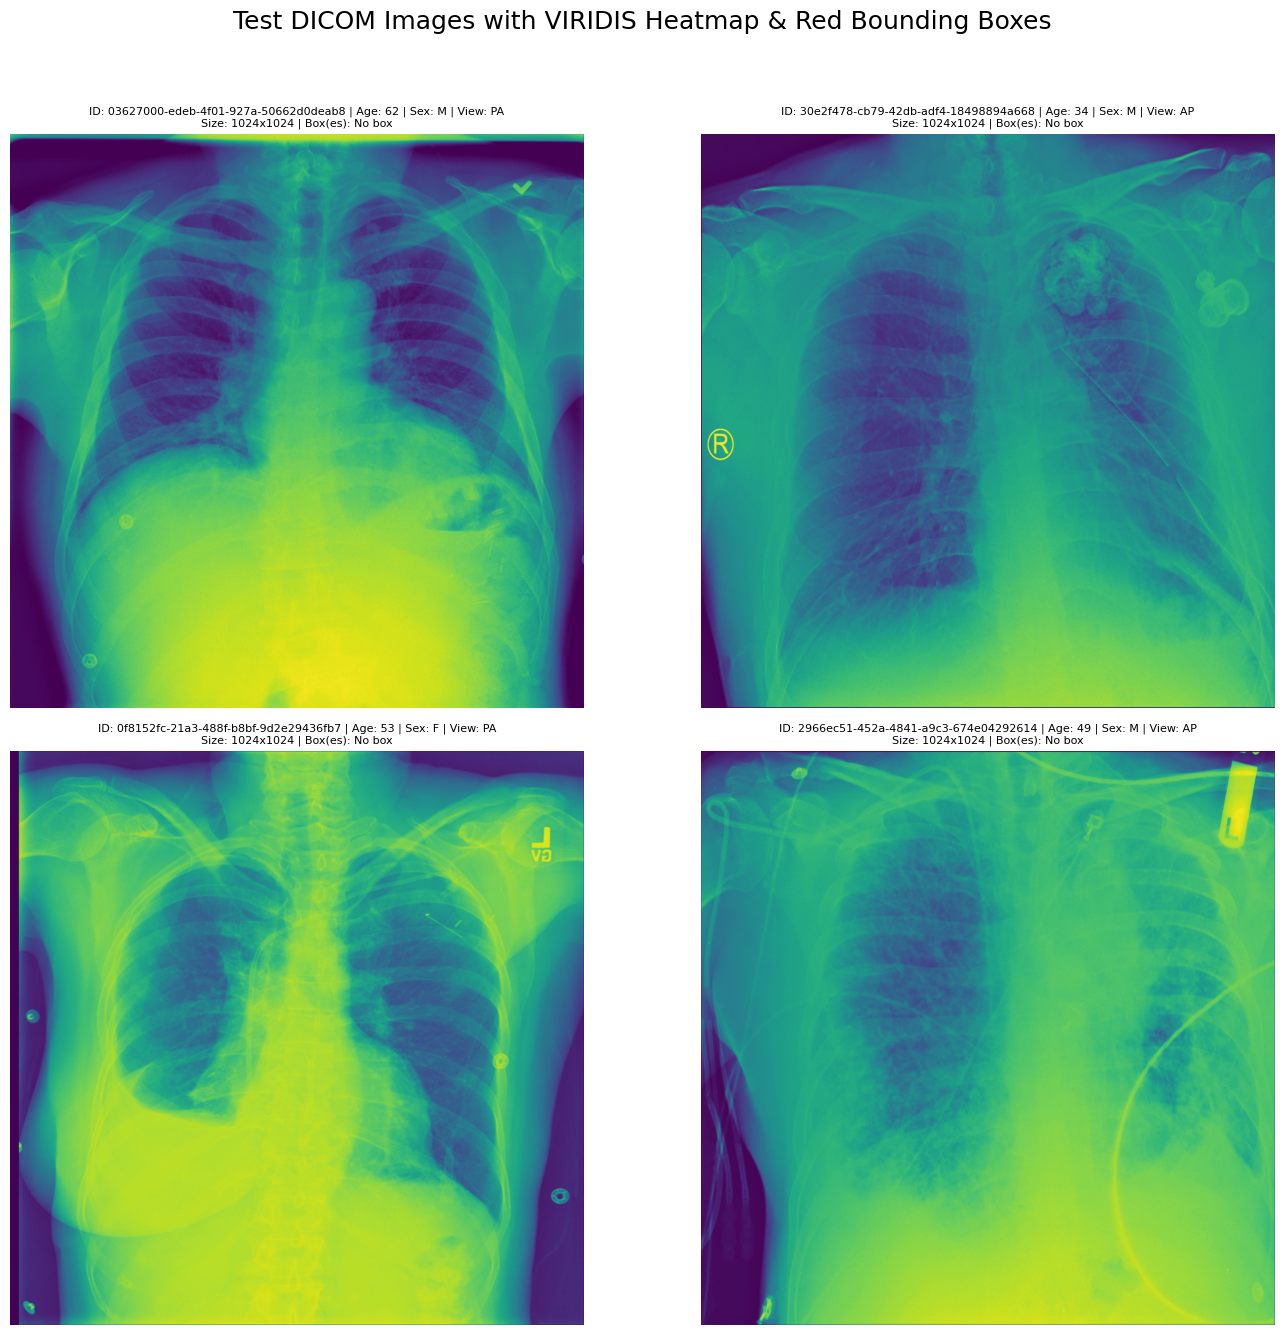

In [ ]:
process_and_display_with_boxes(test_samples, "Test DICOM Images with VIRIDIS Heatmap & Red Bounding Boxes")

In [ ]:
import pandas as pd
import numpy as np
from PIL import Image, ImageDraw

# Parameters
image_size = (64, 64)
csv_path = r"C:\Users\samya\PyCharmProject\Pneumonia-Detection_dataset\data\stage_2_train_labels.csv"

# Load bounding box annotations
df = pd.read_csv(csv_path)
df = df[df['Target'] == 1]  # Only pneumonia cases
grouped = df.groupby('patientId')

# Generate binary masks
masks = {}
for patient_id, rows in grouped:
    mask = Image.new('L', image_size, 0)
    draw = ImageDraw.Draw(mask)
    for _, row in rows.iterrows():
        x, y, w, h = row['x'], row['y'], row['width'], row['height']
        scale_x = image_size[0] / 1024
        scale_y = image_size[1] / 1024
        x1 = int(x * scale_x)
        y1 = int(y * scale_y)
        x2 = int((x + w) * scale_x)
        y2 = int((y + h) * scale_y)
        draw.rectangle([x1, y1, x2, y2], fill=1)
    masks[patient_id] = np.array(mask)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 216ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step


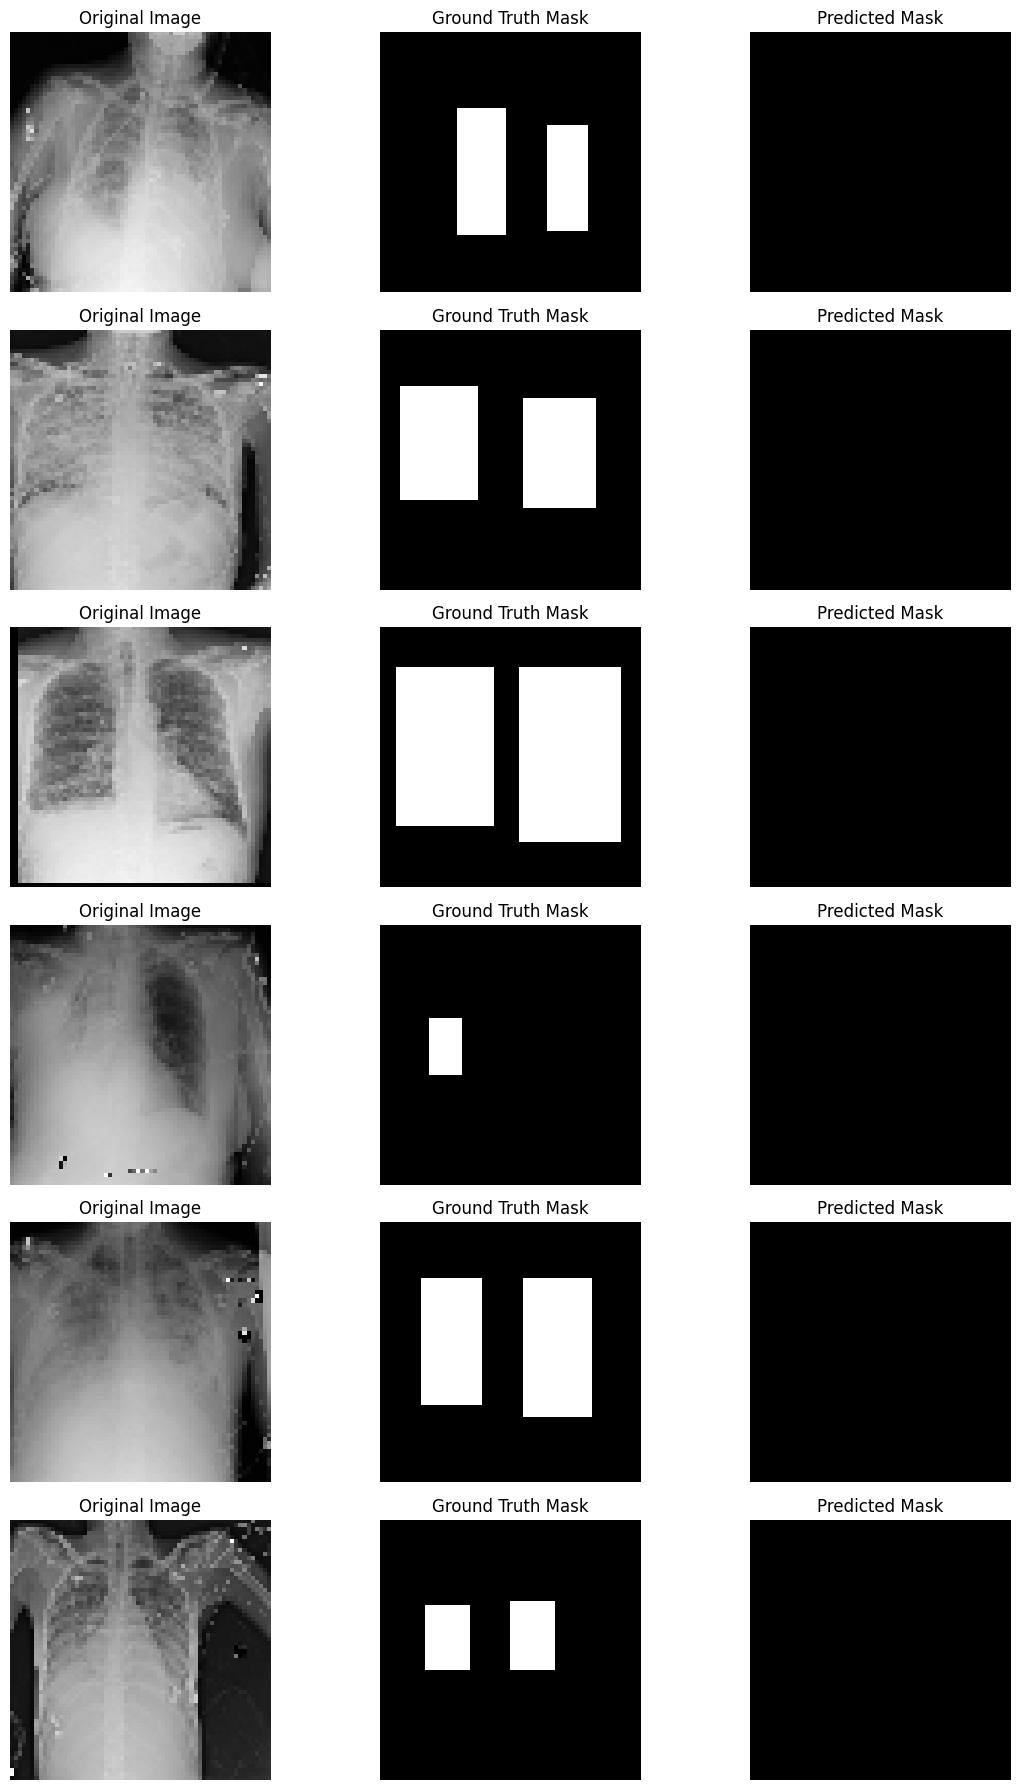

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model

# Load model
model = load_model(r"C:\Users\samya\PyCharmProject\Pneumonia-Detection\xray_model.h5")

# Load image and mask data
image_dir = "npy_images"
image_files = sorted([f for f in os.listdir(image_dir) if f.endswith('.npy')])
num_samples = 6

# Plot
fig, axes = plt.subplots(num_samples, 3, figsize=(12, num_samples * 3))
for i in range(num_samples):
    fname = image_files[i]
    patient_id = os.path.splitext(fname)[0]

    # Load image
    image = np.load(os.path.join(image_dir, fname)) / 255.0
    input_image = np.expand_dims(image, axis=0)

    # Predict mask
    pred_mask = model.predict(input_image)[0, :, :, 0]
    pred_mask_bin = (pred_mask > 0.5).astype(np.uint8)

    # Load ground truth mask
    gt_mask = masks.get(patient_id, np.zeros((64, 64)))

    # Plot original image
    axes[i, 0].imshow(image)
    axes[i, 0].set_title("Original Image")
    axes[i, 0].axis('off')

    # Plot ground truth mask
    axes[i, 1].imshow(gt_mask, cmap='gray')
    axes[i, 1].set_title("Ground Truth Mask")
    axes[i, 1].axis('off')

    # Plot predicted mask
    axes[i, 2].imshow(pred_mask_bin, cmap='gray')
    axes[i, 2].set_title("Predicted Mask")
    axes[i, 2].axis('off')

plt.tight_layout()
plt.show()


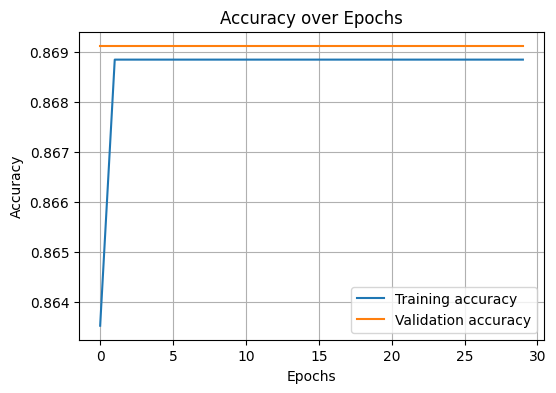

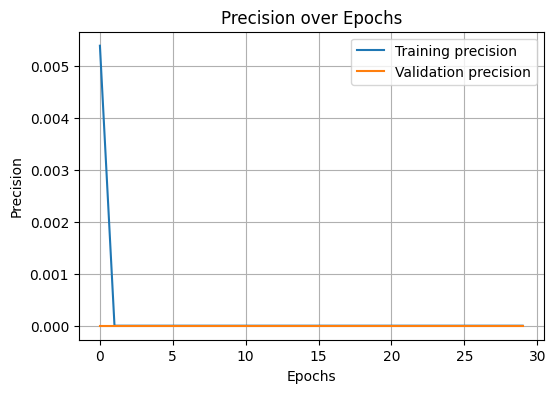

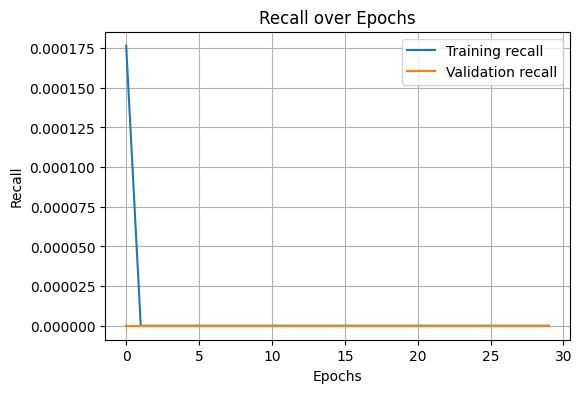

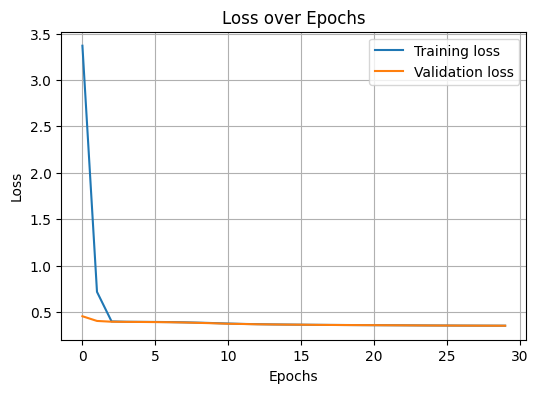

In [ ]:
import matplotlib.pyplot as plt

metrics = ['accuracy', 'precision', 'recall', 'auc', 'loss']

for metric in metrics:
    if metric in history_unet.history:
        plt.figure(figsize=(6, 4))
        plt.plot(history_unet.history[metric], label=f'Training {metric}')
        val_metric = f'val_{metric}'
        if val_metric in history_unet.history:
            plt.plot(history_unet.history[val_metric], label=f'Validation {metric}')
        plt.title(f'{metric.capitalize()} over Epochs')
        plt.xlabel('Epochs')
        plt.ylabel(metric.capitalize())
        plt.legend()
        plt.grid(True)
        #plt.tight_layout()
        plt.show()


100%|██████████| 5000/5000 [01:16<00:00, 65.24it/s]



Epoch 1: LearningRateScheduler setting learning rate to 0.01.
Epoch 1/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 671ms/step - AUC: 0.5017 - accuracy: 0.5760 - loss: 2.2701 - precision: 0.3525 - recall: 0.2461
Epoch 1: val_loss improved from inf to 0.63799, saving model to best_unet.h5


125/125 ━━━━━━━━━━━━━━━━━━━━ 97s 733ms/step - AUC: 0.5016 - accuracy: 0.5764 - loss: 2.2611 - precision: 0.3525 - recall: 0.2447 - val_AUC: 0.5000 - val_accuracy: 0.6760 - val_loss: 0.6380 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0100

Epoch 2: LearningRateScheduler setting learning rate to 0.008912509381337455.
Epoch 2/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 709ms/step - AUC: 0.4948 - accuracy: 0.6472 - loss: 0.6506 - precision: 0.0000e+00 - recall: 0.0000e+00
Epoch 2: val_loss improved from 0.63799 to 0.63222, saving model to best_unet.h5


125/125 ━━━━━━━━━━━━━━━━━━━━ 98s 784ms/step - AUC: 0.4948 - accuracy: 0.6472 - loss: 0.6506 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_AUC: 0.5000 - val_accuracy: 0.6760 - val_loss: 0.6322 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0089

Epoch 3: LearningRateScheduler setting learning rate to 0.007943282347242816.
Epoch 3/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - AUC: 0.4855 - accuracy: 0.6441 - loss: 0.6511 - precision: 0.0000e+00 - recall: 0.0000e+00
Epoch 3: val_loss improved from 0.63222 to 0.63177, saving model to best_unet.h5


125/125 ━━━━━━━━━━━━━━━━━━━━ 221s 1s/step - AUC: 0.4856 - accuracy: 0.6441 - loss: 0.6511 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_AUC: 0.5000 - val_accuracy: 0.6760 - val_loss: 0.6318 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0079

Epoch 4: LearningRateScheduler setting learning rate to 0.0070794578438413795.
Epoch 4/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 798ms/step - AUC: 0.4859 - accuracy: 0.6562 - loss: 0.6440 - precision: 0.0000e+00 - recall: 0.0000e+00
Epoch 4: val_loss did not improve from 0.63177
125/125 ━━━━━━━━━━━━━━━━━━━━ 107s 855ms/step - AUC: 0.4859 - accuracy: 0.6561 - loss: 0.6440 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_AUC: 0.5000 - val_accuracy: 0.6760 - val_loss: 0.6330 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0071

Epoch 5: LearningRateScheduler setting learning rate to 0.006309573444801933.
Epoch 5/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - AUC: 0.4979 - accuracy: 0.6454 - loss: 0.6504 -

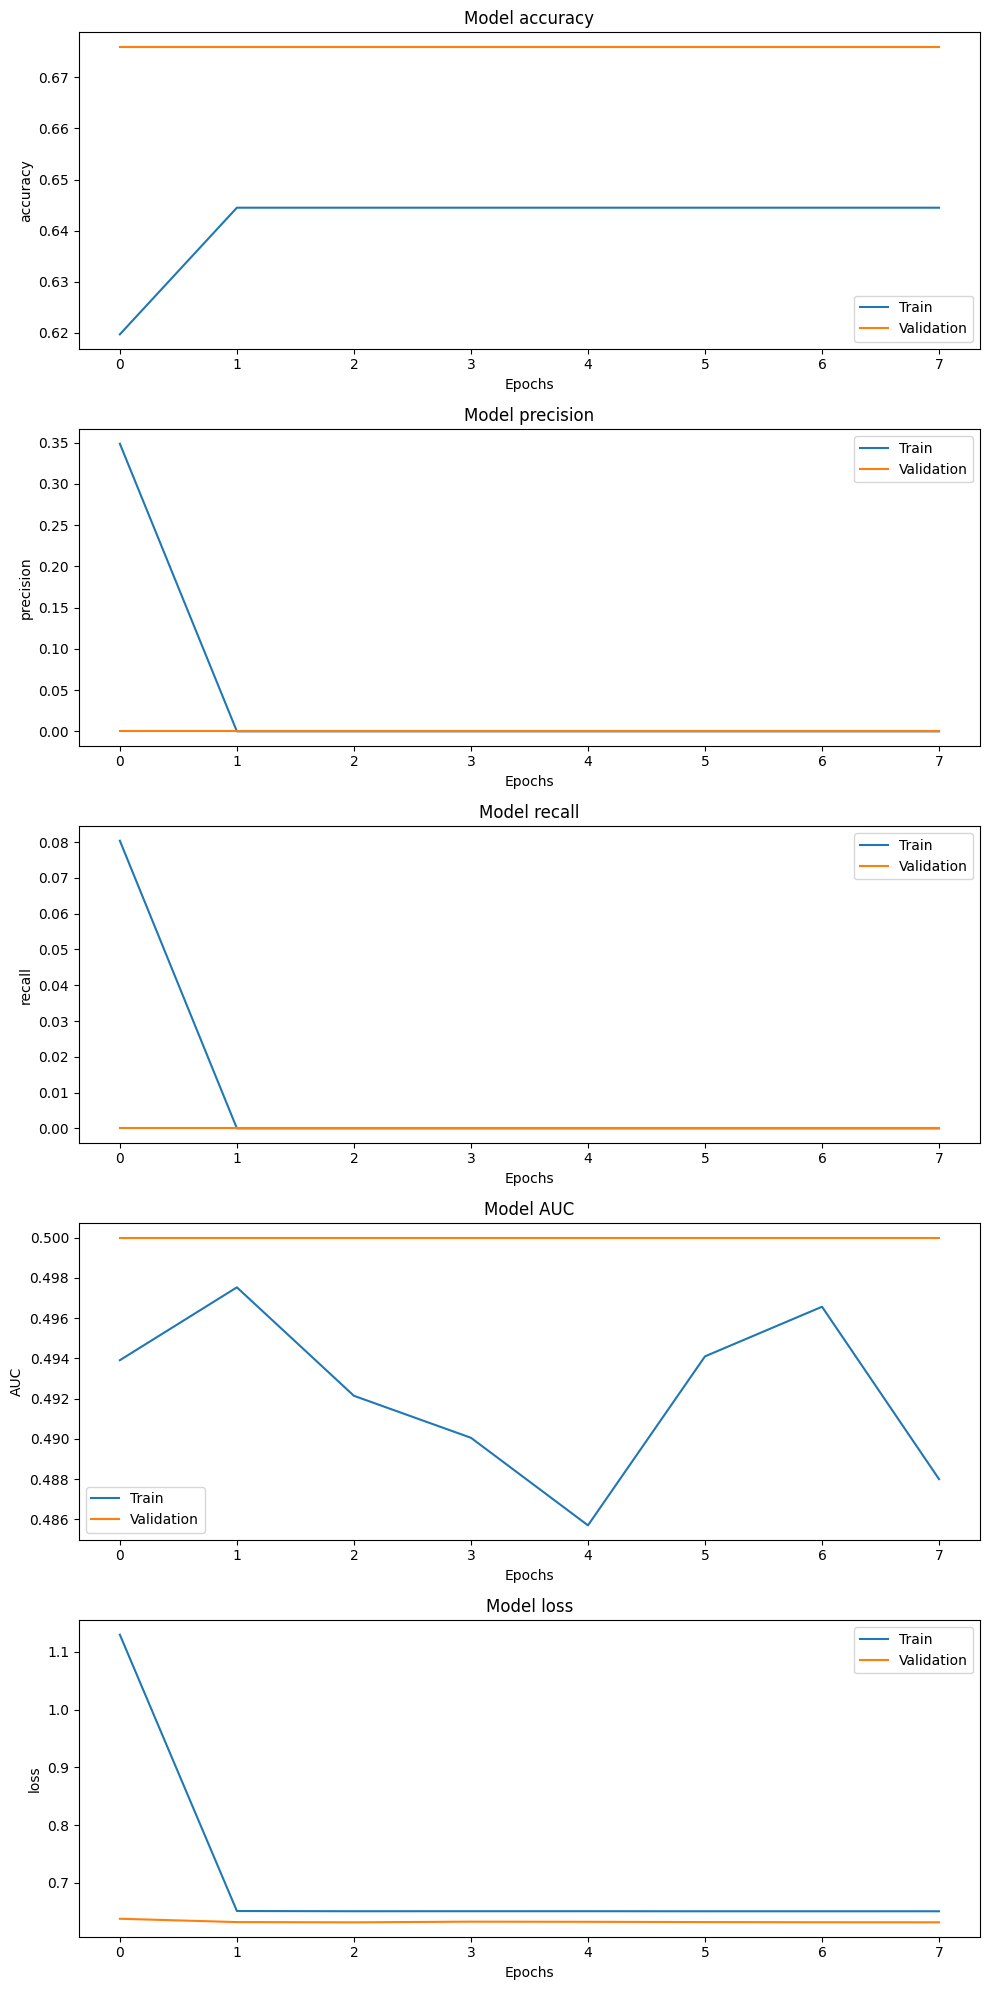

In [ ]:
import os
import numpy as np
import pandas as pd
import cv2
import pydicom
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras import layers, models, Input
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, LearningRateScheduler

# --- Utility Functions ---
def get_dicom_paths(directory_path):
    return [os.path.join(directory_path, file)
            for file in os.listdir(directory_path)
            if file.lower().endswith('.dcm')]

def parse_metadata(dcm):
    unpacked_data = {}
    for tag, elem in dcm.items():
        unpacked_data[elem.keyword] = elem.value
    return unpacked_data

def decode_image(file_path):
    image = pydicom.dcmread(file_path).pixel_array
    image = cv2.resize(image, (64, 64))
    return image / 255.0

# --- Load and Prepare Data ---
TRAIN_IMG_DIR = "C:/Users/samya/PyCharmProject/Pneumonia-Detection_dataset/data/stage_2_train_images"
train_img_paths = get_dicom_paths(TRAIN_IMG_DIR)

labels_df = pd.read_csv("C:/Users/samya/PyCharmProject/Pneumonia-Detection_dataset/data/stage_2_train_labels.csv")
labels_map = labels_df.drop_duplicates('patientId').set_index('patientId')['Target'].to_dict()

X = []
y = []

for path in tqdm(train_img_paths[:5000]):
    filename = os.path.basename(path).replace(".dcm", "")
    label = labels_map.get(filename)
    if label is not None:
        img = decode_image(path)
        X.append(img)
        y.append(label)

X = np.array(X)
y = np.array(y)

# Format for U-Net (add channels and mask format)
X = np.repeat(X[..., np.newaxis], 3, axis=-1)
y = y.reshape(-1, 1, 1, 1)
y = np.repeat(y, 64, axis=1)
y = np.repeat(y, 64, axis=2)

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# --- Model Definition ---
def conv_block(x, filters):
    x = layers.Conv2D(filters, 3, activation='relu', padding='same')(x)
    x = layers.Conv2D(filters, 3, activation='relu', padding='same')(x)
    return x

def encoder_block(x, filters):
    f = conv_block(x, filters)
    p = layers.MaxPooling2D(pool_size=(2, 2))(f)
    return f, p

def decoder_block(x, skip, filters):
    x = layers.Conv2DTranspose(filters, kernel_size=2, strides=2, padding='same')(x)
    x = layers.Concatenate()([x, skip])
    return conv_block(x, filters)

def build_unet(input_shape=(64, 64, 3)):
    inputs = Input(input_shape)

    f1, p1 = encoder_block(inputs, 32)
    f2, p2 = encoder_block(p1, 64)
    f3, p3 = encoder_block(p2, 128)

    b = conv_block(p3, 256)

    d1 = decoder_block(b, f3, 128)
    d2 = decoder_block(d1, f2, 64)
    d3 = decoder_block(d2, f1, 32)

    outputs = layers.Conv2D(1, 1, activation='sigmoid')(d3)

    model = models.Model(inputs, outputs, name='UNet')
    return model

# --- Callbacks and Training ---
def exponential_decay(lr_initial, decay_steps, decay_rate=0.1):
    def schedule(epoch):
        return lr_initial * decay_rate ** (epoch / decay_steps)
    return schedule

checkpoint_cb = ModelCheckpoint("best_unet.h5", save_best_only=True, monitor="val_loss", mode="min", verbose=1)
early_stopping_cb = EarlyStopping(patience=5, restore_best_weights=True)
lr_scheduler_cb = LearningRateScheduler(exponential_decay(0.01, 20), verbose=1)

METRICS = [
    'accuracy',
    tf.keras.metrics.Precision(name='precision'),
    tf.keras.metrics.Recall(name='recall'),
    tf.keras.metrics.AUC(name='AUC')
]

model = build_unet((64, 64, 3))
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=METRICS)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    batch_size=32,
    epochs=20,
    callbacks=[checkpoint_cb, early_stopping_cb, lr_scheduler_cb]
)

# --- Plotting ---
def plot_score(hist):
    fig, ax = plt.subplots(5, 1, figsize=(10, 20))
    ax = ax.ravel()

    for i, met in enumerate(['accuracy', 'precision', 'recall', 'AUC', 'loss']):
        ax[i].plot(hist.history[met])
        ax[i].plot(hist.history['val_' + met])
        ax[i].set_title(f'Model {met}')
        ax[i].set_xlabel('Epochs')
        ax[i].set_ylabel(met)
        ax[i].legend(['Train', 'Validation'])

    plt.tight_layout()
    plt.show()

plot_score(history)
